In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx


In [2]:
# Filter
target_categories = {
    'Accommodation': ['0101'],
    'Eating and Drinking': ['0102'],
    'Attractions': ['03'],
    'Sport and Entertainment': ['0421', '0423', '0424', '0425'],
    'Education': ['0531', '0532'],
    'Health': ['0528'],
    'Retail': ['09'],
    'Transport': ['1053', '10570731', '10570756', '10570738', '10570761', '10590732', '10590759']
}

path = "D:/PythonProjects/Airbnb-Performace/poi-2025_03.csv" 

df = pd.read_csv(
        path, 
        sep='|', 
        dtype={'pointx_class': str},
        usecols=['name', 'pointx_class', 'feature_easting', 'feature_northing'],
        encoding='latin-1',
        on_bad_lines='skip' 
    )

all_target_codes = [code for sublist in target_categories.values() for code in sublist]

print(f"   Total rows: {len(df)}")
print(f"   Columns: {list(df.columns)}")

   Total rows: 29198
   Columns: ['name', 'pointx_class', 'feature_easting', 'feature_northing']


In [ ]:
# Check if ClassCode starts with any code we define
def is_target_poi(code):
    if pd.isna(code): return False
    return any(code.startswith(target) for target in all_target_codes)

# Apply
df_filtered = df[df['pointx_class'].apply(is_target_poi)].copy()

print(f"Origin data: {len(df)} ")
print(f"Filtered data: {len(df_filtered)} ")

Origin data: 29198 条
Filtered data: 13827 条


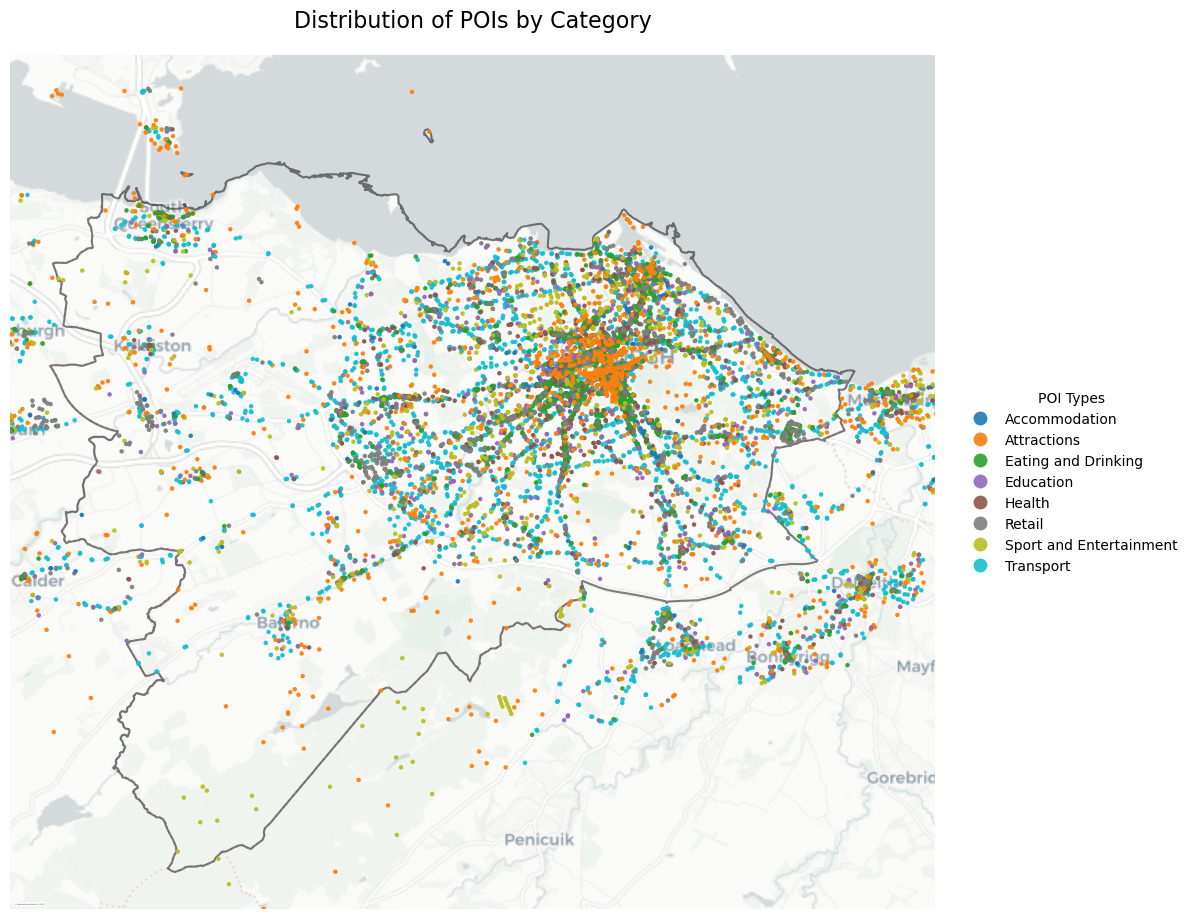

In [4]:
# POI convert to Web Mercator
gdf_poi = gpd.GeoDataFrame(
    df_filtered, 
    geometry=gpd.points_from_xy(df_filtered['feature_easting'], df_filtered['feature_northing']),
    crs="EPSG:27700"
).to_crs(epsg=3857)

# Classify
def get_category(code):
    if pd.isna(code): return None
    for cat_name, codes in target_categories.items():
        if any(str(code).startswith(c) for c in codes):
            return cat_name
    return None

gdf_poi['Category'] = gdf_poi['pointx_class'].apply(get_category)
gdf_plot = gdf_poi.dropna(subset=['Category'])

# Read boundaries
boundary_path = r"E:\Arcgisproject\edinbound"
gdf_bound = gpd.read_file(boundary_path).to_crs(epsg=3857)

# Drawing
minx, miny, maxx, maxy = gdf_bound.total_bounds
# (Height / Width)
ratio = (maxy - miny) / (maxx - minx)
fig, ax = plt.subplots(figsize=(12, 12 * ratio))

gdf_bound.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.5,
    zorder=2
)

gdf_plot.plot(
    ax=ax, 
    column='Category', 
    categorical=True, 
    legend=True, 
    cmap='tab10', 
    markersize=5,
    alpha=0.9,
    zorder=3,
    legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1.02, 0.5), 'title': 'POI Types', 'frameon': False} 
)

# Adjust display range
ax.set_xlim(minx - (maxx-minx)*0.05, maxx + (maxx-minx)*0.1)
ax.set_ylim(miny - (maxy-miny)*0.05, maxy + (maxy-miny)*0.1)

# Add base map
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution_size=0)
except:
    print("Error")
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title('Distribution of POIs by Category', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

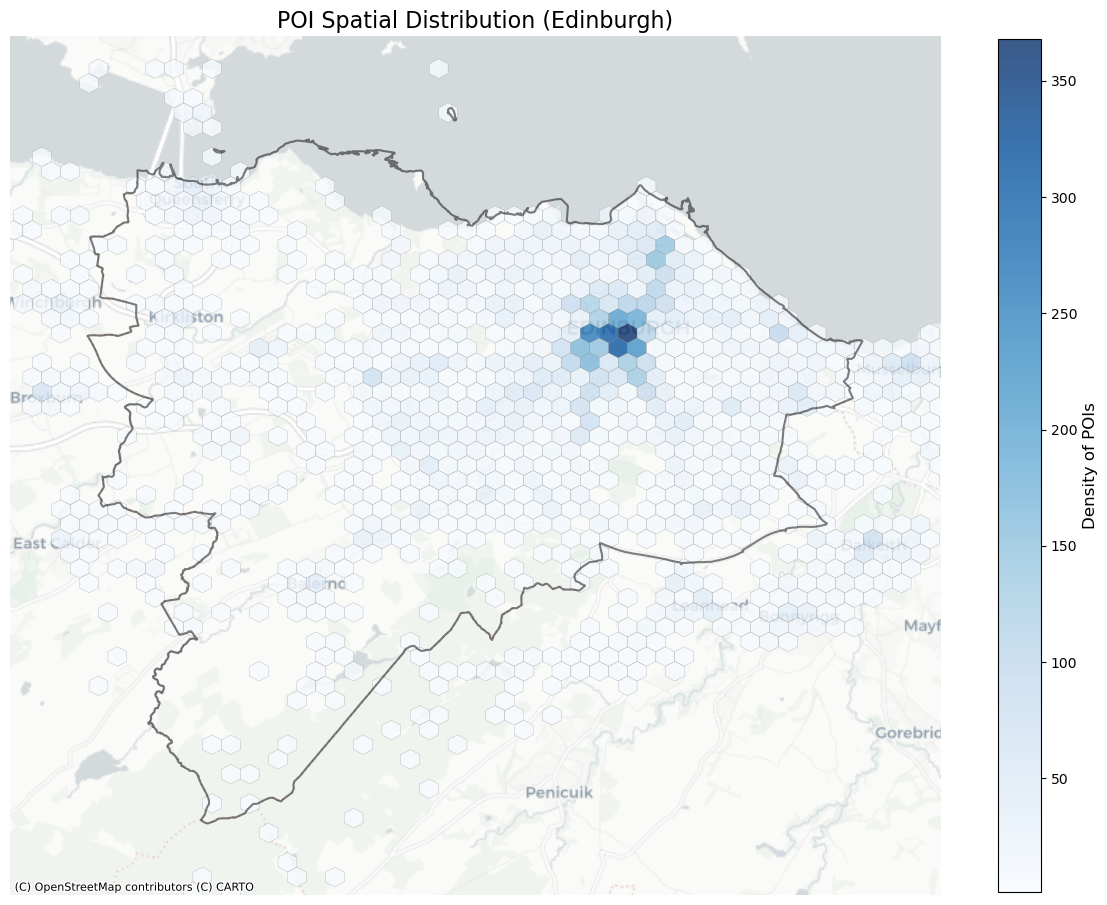

In [5]:
# Drawing Hexbin
minx, miny, maxx, maxy = gdf_bound.total_bounds
ratio = (maxy - miny) / (maxx - minx)

fig, ax = plt.subplots(figsize=(15, 15 * ratio))

gdf_poi = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered['feature_easting'], df_filtered['feature_northing']),
        crs="EPSG:27700"
    )

gdf_web = gdf_poi.to_crs(epsg=3857)

# Hexbin 
hb = ax.hexbin(
    gdf_web.geometry.x, 
    gdf_web.geometry.y, 
    gridsize=50,
    cmap='Blues', 
    mincnt=1,
    alpha=0.8,
    linewidths=0.2,
    edgecolors='grey'
)

gdf_bound.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.5
)

ax.set_xlim(minx - (maxx-minx)*0.1, maxx + (maxx-minx)*0.1)
ax.set_ylim(miny - (maxy-miny)*0.1, maxy + (maxy-miny)*0.1)
ax.set_aspect('equal', adjustable='box')

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f"error: {e}")
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)


cb = plt.colorbar(hb, ax=ax, shrink=0.8)
cb.set_label('Density of POIs', fontsize=12)

ax.set_axis_off()
plt.title('POI Spatial Distribution (Edinburgh)', fontsize=16)
plt.show()

In [6]:
# Buffer Analysis
# Prepare Airbnb property data
listings_path = r"D:\PythonProjects\Airbnb-Performace\MergedEdinburgh\2024-02-18_listings.csv.gz"
df_listings = pd.read_csv(listings_path, low_memory=False)
df_listings = df_listings.dropna(subset=['latitude', 'longitude'])

gdf_listings = gpd.GeoDataFrame(
    df_listings,
    geometry=gpd.points_from_xy(df_listings.longitude, df_listings.latitude),
    crs="EPSG:4326"
)

# Convert coordinate system and the unit to meters
gdf_listings = gdf_listings.to_crs("EPSG:27700")

# Perpare POI data
if gdf_poi.crs.to_string() != "EPSG:27700":
    gdf_poi = gdf_poi.to_crs("EPSG:27700")

print("The coordinate system conversion has been completed, and the unit has been unified to meters.")

The coordinate system conversion has been completed, and the unit has been unified to meters.


In [ ]:
def get_category(code):
    if pd.isna(code): return None
    for cat, codes in target_categories.items():
        if any(code.startswith(c) for c in codes):
            return cat
    return None

gdf_poi['Category'] = gdf_poi['pointx_class'].apply(get_category)
gdf_poi = gdf_poi.dropna(subset=['Category'])

# Buffer distance
distances = [500, 800, 1500]

# Create a copy to prevent original data
gdf_analysis = gdf_listings.copy()

print("start analysis")

for dist in distances:
    print(f"\ndeal {dist} meter buffer...")
    
    # 1. Buffer
    buffered_listings = gdf_listings.copy()
    buffered_listings['geometry'] = buffered_listings.geometry.buffer(dist)
    
    # 2. Spatial Join
    joined = gpd.sjoin(buffered_listings, gdf_poi[['Category', 'geometry']], how='inner', predicate='intersects')
    
    # 3. Group Count (by Property ID and POI Category)
    counts = joined.groupby([joined.index, 'Category']).size().unstack(fill_value=0)
    
    # 4. Rename the column
    counts.columns = [f"{col}_{dist}m" for col in counts.columns]
    
    # 5. Merge back into the main table
    gdf_analysis = gdf_analysis.merge(counts, left_index=True, right_index=True, how='left')
    gdf_analysis[f'Total_POI_{dist}m'] = counts.sum(axis=1)

    del buffered_listings, joined
    gc.collect()

gdf_analysis = gdf_analysis.fillna(0)

print("\ncompleted")
print("newly generated：")
print([col for col in gdf_analysis.columns if 'm' in col][-10:])

In [ ]:
# Pick radom house
sample_house = gdf_listings.iloc[100:101]
buffer_800 = sample_house.geometry.buffer(800)

# clip
pois_in_buffer = gdf_poi.clip(buffer_800)

# Drawing
fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoSeries(buffer_800).plot(ax=ax, color='blue', alpha=0.1, edgecolor='blue', linewidth=2, label='800m Buffer')

sample_house.plot(ax=ax, color='red', markersize=500, marker='*', label='Airbnb Listing')

pois_in_buffer.plot(ax=ax, column='Category', cmap='tab10', markersize=20, legend=True)

try:
    ctx.add_basemap(ax, crs=gdf_listings.crs.to_string(), source=ctx.providers.CartoDB.Positron)
except:
    pass

plt.title(f"Buffer Analysis Sample (800m)\nContains {len(pois_in_buffer)} POIs")
plt.show()

In [9]:
# Save as CSV
output_path = r"D:\PythonProjects\Airbnb-Performace\202402_listings_with_POIbuffer.csv"
pd.DataFrame(gdf_analysis.drop(columns='geometry')).to_csv(output_path, index=False)

print(f"Result saved as: {output_path}")

# Check new features
new_features = [col for col in gdf_analysis.columns if '00m' in col]
print("Newly generated(head 10):")
print(new_features[:10])

# Simple statistical description
print("Overview (Mean):")
print(gdf_analysis[new_features].mean().head())

Result saved as: D:\PythonProjects\Airbnb-Performace\202402_listings_with_POIbuffer.csv
Newly generated(head 10):
['Accommodation_500m', 'Attractions_500m', 'Eating and Drinking_500m', 'Education_500m', 'Health_500m', 'Retail_500m', 'Sport and Entertainment_500m', 'Transport_500m', 'Total_POI_500m', 'Accommodation_800m']
Overview (Mean):
Accommodation_500m          10.202620
Attractions_500m            30.556769
Eating and Drinking_500m    90.637263
Education_500m               9.149927
Health_500m                 18.287918
dtype: float64
